# Galaxy Zoo 2 — Exploratory Data Analysis

**Proyecto:** Galaxy Morph — Clasificación morfológica de galaxias con CNN  
**Dataset:** Galaxy Zoo 2 (GZ2) + Hart et al. (2016) debiased vote fractions  
**Objetivo de este notebook:** Explorar los datos disponibles, comprender el árbol de decisión del GZ2, y determinar qué clases morfológicas son viables para el entrenamiento del modelo.

---

## Pipeline general del proyecto

```
gz2_hart16.csv  ──┐
                   ├──► Merge ──► Definición de clases ──► Dataset final ──► CNN
gz2_filename_mapping.csv ──┘         (umbrales)              (balanceado)
images_gz2/images ──────────────────────────────────────────────────────────────►
```

## Clases morfológicas objetivo (Esquema Hubble–de Vaucouleurs)

| Clase | Descripción | Indicadores GZ2 |
|-------|-------------|-----------------|
| **Elliptical** | Esferoides sin estructura interna | `t01` smooth alto, `t07` redondeada |
| **Lenticular (S0)** | Disco plano sin brazos espirales | `t01` features + `t04` no spiral + no edge-on |
| **Spiral** | Espirales sin barra | `t01` features + `t04` spiral + `t03` no bar |
| **Barred Spiral** | Espirales con barra central | `t01` features + `t04` spiral + `t03` bar |
| **Edge-on** | Galaxias vistas de canto | `t01` features + `t02` edge-on yes |
| **Irregular / Merger** | Sin forma definida, fusiones | `t06` odd + `t08` merger/disturbed |

---
## Sección 1 — Importación de librerías y configuración de rutas

In [2]:
import os
import pathlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Matplotlib style
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#e6edf3",
    "xtick.color":      "#e6edf3",
    "ytick.color":      "#e6edf3",
    "text.color":       "#e6edf3",
    "grid.color":       "#21262d",
    "grid.linestyle":   "--",
    "grid.alpha":       0.5,
    "figure.titlesize": 14,
    "axes.titlesize":   12,
    "axes.labelsize":   10,
    "font.family":      "DejaVu Sans",
})

print("Libraries loaded ✓")

Libraries loaded ✓


In [3]:
# Path configuration (Kaggle-compatible)
# On Kaggle the two datasets are mounted at different input paths:
#   - CSVs   : /kaggle/input/datasets/jeancdevx/galaxy-zoo-2/
#   - Images : /kaggle/input/datasets/jaimetrickz/galaxy-zoo-2-images/images_gz2/images/
# Locally everything lives under ../data/

IS_KAGGLE = pathlib.Path("/kaggle/input").exists()

if IS_KAGGLE:
    _KAGGLE_CSV_ROOT    = pathlib.Path("/kaggle/input/datasets/jeancdevx/galaxy-zoo-2")
    _KAGGLE_IMAGES_ROOT = pathlib.Path("/kaggle/input/datasets/jaimetrickz/galaxy-zoo-2-images")
    HART16_PATH  = _KAGGLE_CSV_ROOT    / "gz2_hart16.csv"
    MAPPING_PATH = _KAGGLE_CSV_ROOT    / "gz2_filename_mapping.csv"
    IMAGES_DIR   = _KAGGLE_IMAGES_ROOT / "images_gz2" / "images"
else:
    _LOCAL_ROOT  = pathlib.Path("../data")
    HART16_PATH  = _LOCAL_ROOT / "gz2_hart16.csv"
    MAPPING_PATH = _LOCAL_ROOT / "gz2_filename_mapping.csv"
    IMAGES_DIR   = _LOCAL_ROOT / "images_gz2" / "images"

print(f"Running on Kaggle : {IS_KAGGLE}")
print(f"Hart16 CSV        : {HART16_PATH}")
print(f"Mapping CSV       : {MAPPING_PATH}")
print(f"Images directory  : {IMAGES_DIR}")

Running on Kaggle : False
Hart16 CSV        : ../data/gz2_hart16.csv
Mapping CSV       : ../data/gz2_filename_mapping.csv
Images directory  : ../data/images_gz2/images


---
## Sección 2 — Carga e inspección de `gz2_hart16.csv`

Esta tabla contiene **239,695 galaxias** con las fracciones de votos corregidas por sesgo (método Hart et al. 2016).  
Cada galaxia fue evaluada por ~40 voluntarios respondiendo el árbol de decisión morfológico del GZ2.

In [4]:
hart = pd.read_csv(HART16_PATH)
print(f"Shape  : {hart.shape[0]:,} rows × {hart.shape[1]} columns")
print(f"Memory : {hart.memory_usage(deep=True).sum() / 1e6:.1f} MB")
hart.head(10)

Shape  : 239,695 rows × 231 columns
Memory : 490.2 MB


,dr7objid,ra,dec,rastring,decstring,sample,gz2_class,total_classifications,total_votes,t01_smooth_or_features_a01_smooth_count,t01_smooth_or_features_a01_smooth_weight,t01_smooth_or_features_a01_smooth_fraction,t01_smooth_or_features_a01_smooth_weighted_fraction,t01_smooth_or_features_a01_smooth_debiased,t01_smooth_or_features_a01_smooth_flag,t01_smooth_or_features_a02_features_or_disk_count,t01_smooth_or_features_a02_features_or_disk_weight,t01_smooth_or_features_a02_features_or_disk_fraction,t01_smooth_or_features_a02_features_or_disk_weighted_fraction,t01_smooth_or_features_a02_features_or_disk_debiased,t01_smooth_or_features_a02_features_or_disk_flag,t01_smooth_or_features_a03_star_or_artifact_count,t01_smooth_or_features_a03_star_or_artifact_weight,t01_smooth_or_features_a03_star_or_artifact_fraction,t01_smooth_or_features_a03_star_or_artifact_weighted_fraction,...,t11_arms_number_a32_2_flag,t11_arms_number_a33_3_count,t11_arms_number_a33_3_weight,t11_arms_number_a33_3_fraction,t11_arms_number_a33_3_weighted_fraction,t11_arms_number_a33_3_debiased,t11_arms_number_a33_3_flag,t11_arms_number_a34_4_count,t11_arms_number_a34_4_weight,t11_arms_number_a34_4_fraction,t11_arms_number_a34_4_weighted_fraction,t11_arms_number_a34_4_debiased,t11_arms_number_a34_4_flag,t11_arms_number_a36_more_than_4_count,t11_arms_number_a36_more_than_4_weight,t11_arms_number_a36_more_than_4_fraction,t11_arms_number_a36_more_than_4_weighted_fraction,t11_arms_number_a36_more_than_4_debiased,t11_arms_number_a36_more_than_4_flag,t11_arms_number_a37_cant_tell_count,t11_arms_number_a37_cant_tell_weight,t11_arms_number_a37_cant_tell_fraction,t11_arms_number_a37_cant_tell_weighted_fraction,t11_arms_number_a37_cant_tell_debiased,t11_arms_number_a37_cant_tell_flag
0,587732591714893851,179.0430,60.5225,11:56:10.32,+60:31:21.1,original,Sc+t,45,342,0,0.0000,0.0000,0.0000,0.0000,0,42,42.0000,0.9330,0.9880,0.9880,1,3,0.5060,0.0670,0.0120,...,0,1,1.0000,0.0250,0.0250,0.0246,0,2,2.0000,0.0500,0.0500,0.0496,0,18,18.0000,0.4500,0.4500,0.4826,0,16,16.0000,0.4000,0.4000,0.3945,0
1,588009368545984617,135.0844,52.4942,09:00:20.26,+52:29:39.3,original,Sb+t,42,332,1,1.0000,0.0240,0.0240,0.0240,0,41,40.2050,0.9760,0.9760,0.9760,1,0,0.0000,0.0000,0.0000,...,0,2,2.0000,0.0490,0.0500,0.0500,0,1,1.0000,0.0240,0.0250,0.0250,0,21,20.2050,0.5120,0.5030,0.5048,0,13,13.0000,0.3170,0.3230,0.3227,0
2,587732484359913515,183.3720,50.7415,12:13:29.27,+50:44:29.4,original,Ei,36,125,28,28.0000,0.7780,0.7800,0.7800,0,5,5.0000,0.1390,0.1390,0.1390,0,3,2.8920,0.0830,0.0810,...,0,0,0.0000,0.0000,0.0000,0.0000,0,0,0.0000,0.0000,0.0000,0.0000,0,0,0.0000,0.0000,0.0000,0.0000,0,0,0.0000,0.0000,0.0000,0.0000,0
3,587741723357282317,186.2520,28.5586,12:25:00.47,+28:33:31.0,original,Sc+t,28,218,1,1.0000,0.0360,0.0360,0.0360,0,27,27.0000,0.9640,0.9640,0.9640,1,0,0.0000,0.0000,0.0000,...,0,6,6.0000,0.2400,0.2400,0.2401,0,5,5.0000,0.2000,0.2000,0.2001,0,6,6.0000,0.2400,0.2400,0.2413,0,6,6.0000,0.2400,0.2400,0.2398,0
4,587738410866966577,161.0864,14.0845,10:44:20.73,+14:05:04.1,original,Er,43,151,33,33.0000,0.7670,0.7670,0.7670,0,8,8.0000,0.1860,0.1860,0.1860,0,2,2.0000,0.0470,0.0470,...,0,0,0.0000,0.0000,0.0000,0.0000,0,0,0.0000,0.0000,0.0000,0.0000,0,0,0.0000,0.0000,0.0000,0.0000,0,0,0.0000,0.0000,0.0000,0.0000,0
5,587729751132209314,246.9214,40.9270,16:27:41.13,+40:55:37.1,extra,Ei,48,154,41,41.0000,0.8540,0.8610,0.8610,1,3,3.0000,0.0620,0.0630,0.0630,0,4,3.6090,0.0830,0.0760,...,0,0,0.0000,0.0000,0.0000,0.0000,0,0,0.0000,0.0000,0.0000,0.0000,0,0,0.0000,0.0000,0.0000,0.0000,0,0,0.0000,0.0000,0.0000,0.0000,0
6,587733608555216981,249.4746,36.0730,16:37:53.91,+36:04:22.9,original,Ei,39,142,25,25.0000,0.6410,0.6490,0.6490,0,11,11.0000,0.2820,0.2860,0.2860,0,3,2.4920,0.0770,0.0650,...,0,0,0.0000,0.0000,0.0000,0.0000,0,0,0.0000,0.0000,0.0000,0.0000,0,0,0.0000,0.0000,0.0000,0.0000,0,0,0.0000,0.0000,0.0000,0.0000,0
7,587735742617616406,243.1468,29.3651,16:12:35.22,+29:21:54.2,original,Sb+t,35,282,0,0.0000,0.000

In [5]:
# Column inventory: metadata vs vote-fraction columns
meta_cols  = [c for c in hart.columns if not c.startswith("t0") and not c.startswith("t1")]
vote_cols  = [c for c in hart.columns if c.startswith("t0") or c.startswith("t1")]

print(f"Metadata columns    : {len(meta_cols)}")
print(f"Vote-fraction cols  : {len(vote_cols)}")
print()
print("Metadata columns:")
for c in meta_cols:
    print(f"  {c}")

Metadata columns    : 9
Vote-fraction cols  : 222

Metadata columns:
  dr7objid
  ra
  dec
  rastring
  decstring
  sample
  gz2_class
  total_classifications
  total_votes


In [6]:
# Vote-fraction columns grouped by decision-tree question
import re
tasks = {}
for c in vote_cols:
    m = re.match(r"(t\d{2}_\w+?)_(a\d{2}_)", c)
    if m:
        task_key = m.group(1)
        tasks.setdefault(task_key, []).append(c)

print(f"Decision-tree tasks found: {len(tasks)}\n")
for task, cols in tasks.items():
    print(f"  {task}  →  {len(cols)} columns")

Decision-tree tasks found: 11

  t01_smooth_or_features  →  18 columns
  t02_edgeon  →  12 columns
  t03_bar  →  12 columns
  t04_spiral  →  12 columns
  t05_bulge_prominence  →  24 columns
  t06_odd  →  12 columns
  t07_rounded  →  18 columns
  t08_odd_feature  →  42 columns
  t09_bulge_shape  →  18 columns
  t10_arms_winding  →  18 columns
  t11_arms_number  →  36 columns


In [7]:
# Missing values
missing = hart.isnull().sum()
missing_pct = (missing / len(hart) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
missing_report = missing_report[missing_report["missing_count"] > 0]

if missing_report.empty:
    print("No missing values found in hart16 table ✓")
else:
    print(f"{len(missing_report)} columns have missing values:")
    display(missing_report)

11 columns have missing values:


,missing_count,missing_%
t02_edgeon_a05_no_debiased,294,0.1200
t03_bar_a07_no_bar_debiased,280,0.1200
t04_spiral_a09_no_spiral_debiased,288,0.1200
t05_bulge_prominence_a13_dominant_debiased,203,0.0800
t06_odd_a14_yes_debiased,276,0.1200
t07_rounded_a16_completely_round_debiased,240,0.1000
t08_odd_feature_a38_dust_lane_debiased,11,0.0000
t09_bulge_shape_a25_rounded_debiased,100,0.0400
t09_bulge_shape_a26_boxy_debiased,40,0.0200
t11_arms_number_a31_1_debiased,6,0.0000


In [8]:
# Basic statistics for classification/vote metadata
stats_cols = ["total_classifications", "total_votes", "gz2_class"]
print("=== total_classifications & total_votes ===")
display(hart[["total_classifications", "total_votes"]].describe().T)

print("\n=== gz2_class value counts (top 20) ===")
display(hart["gz2_class"].value_counts().head(20).rename_axis("gz2_class").reset_index(name="count"))

=== total_classifications & total_votes ===


,count,mean,std,min,25%,50%,75%,max
total_classifications,239695.0000,42.5697,5.8569,16.0000,39.0000,43.0000,46.0000,79.0000
total_votes,239695.0000,179.0246,60.7291,30.0000,140.0000,156.0000,196.0000,604.0000



=== gz2_class value counts (top 20) ===


,gz2_class,count
0,Ei,44038
1,Er,36764
2,Ser,14009
3,Sc?t,13509
4,Ec,10149
5,Sb,6932
6,SBc2m,5862
7,Sc,5776
8,Sb?t,5431
9,Sen,4450


---
## Sección 3 — Carga e inspección de `gz2_filename_mapping.csv`

Esta tabla vincula cada `objid` del SDSS con el `asset_id` que corresponde al nombre del archivo de imagen (e.g., `asset_id=1234` → `1234.jpg`).  
Contiene tanto imágenes *original* como *preprocessed*.

In [9]:
mapping = pd.read_csv(MAPPING_PATH)
print(f"Shape : {mapping.shape[0]:,} rows × {mapping.shape[1]} columns")
mapping.head(10)

Shape : 355,990 rows × 3 columns


,objid,sample,asset_id
0,587722981736120347,original,1
1,587722981736579107,original,2
2,587722981741363294,original,3
3,587722981741363323,original,4
4,587722981741559888,original,5
5,587722981741625481,original,6
6,587722981741625484,original,7
7,587722981741625520,original,8
8,587722981741625545,original,9
9,587722981741691055,original,10


In [10]:
# Sample type breakdown
print("=== Sample type counts ===")
display(mapping["sample"].value_counts().rename_axis("sample").reset_index(name="count"))

# Duplicate objid check
dup_objid = mapping.duplicated(subset=["objid"], keep=False).sum()
print(f"\nRows with duplicate objid : {dup_objid:,}")
print("(Expected: each objid appears in 'original' AND 'preprocessed' → duplicates are normal)")

# Unique galaxies
unique_galaxies = mapping["objid"].nunique()
print(f"\nUnique galaxy objids      : {unique_galaxies:,}")

=== Sample type counts ===


,sample,count
0,original,245609
1,stripe82_coadd_1,30346
2,stripe82_coadd_2,30339
3,extra,28174
4,stripe82,21522



Rows with duplicate objid : 60,678
(Expected: each objid appears in 'original' AND 'preprocessed' → duplicates are normal)

Unique galaxy objids      : 325,651


---
## Sección 4 — Merge de tablas

Combinamos `gz2_hart16` con la tabla de mapping para obtener el `asset_id` (nombre de imagen) de cada galaxia.  
Usaremos únicamente las entradas `sample == "original"` para evitar duplicados.

In [11]:
# Keep only 'original' sample entries to avoid duplicating rows
mapping_orig = mapping[mapping["sample"] == "original"].copy()
mapping_orig = mapping_orig.rename(columns={"objid": "dr7objid"})

print(f"Hart16 rows           : {len(hart):,}")
print(f"Mapping (original)    : {len(mapping_orig):,}")

# Merge on objid
merged = hart.merge(mapping_orig[["dr7objid", "asset_id"]], on="dr7objid", how="left")

print(f"\nMerged rows           : {len(merged):,}")
print(f"Rows with asset_id    : {merged['asset_id'].notna().sum():,}")
print(f"Rows WITHOUT asset_id : {merged['asset_id'].isna().sum():,} (galaxies in hart16 with no mapping entry)")

Hart16 rows           : 239,695
Mapping (original)    : 245,609

Merged rows           : 239,695
Rows with asset_id    : 209,294
Rows WITHOUT asset_id : 30,401 (galaxies in hart16 with no mapping entry)


In [12]:
# Galaxies in mapping that are NOT in hart16
mapping_ids = set(mapping_orig["dr7objid"])
hart_ids    = set(hart["dr7objid"])

only_in_mapping = mapping_ids - hart_ids
only_in_hart    = hart_ids - mapping_ids
in_both         = hart_ids & mapping_ids

print(f"Galaxies in both tables  : {len(in_both):,}")
print(f"Only in hart16           : {len(only_in_hart):,}  (have labels, no image path)")
print(f"Only in mapping          : {len(only_in_mapping):,}  (have image, no vote data)")

Galaxies in both tables  : 209,294
Only in hart16           : 30,401  (have labels, no image path)
Only in mapping          : 36,315  (have image, no vote data)


---
## Sección 5 — Inventario de imágenes

Comparamos los archivos físicos en el directorio de imágenes contra el merged dataset.

In [13]:
# Scan image directory
image_files = sorted(IMAGES_DIR.glob("*.jpg"))
image_asset_ids = {int(f.stem) for f in image_files}

print(f"Image files on disk       : {len(image_files):,}")
print(f"Unique asset_ids on disk  : {len(image_asset_ids):,}")

# Merge dataset asset_ids
merged_asset_ids = set(merged["asset_id"].dropna().astype(int))

only_on_disk   = image_asset_ids - merged_asset_ids
only_in_merged = merged_asset_ids - image_asset_ids
matched        = image_asset_ids & merged_asset_ids

print(f"\nImages matched to metadata : {len(matched):,}")
print(f"Images with NO metadata    : {len(only_on_disk):,}")
print(f"Metadata with NO image     : {len(only_in_merged):,}")

Image files on disk       : 243,434
Unique asset_ids on disk  : 243,434

Images matched to metadata : 209,240
Images with NO metadata    : 34,194
Metadata with NO image     : 54


In [14]:
# Sample 5 images to inspect dimensions and format
sample_images = np.random.choice(image_files, size=5, replace=False)

print("Sample image properties:")
print(f"{'File':<20} {'Size (px)':<20} {'Mode':<10} {'File size (KB)'}")
print("-" * 65)
for img_path in sample_images:
    with Image.open(img_path) as img:
        file_kb = img_path.stat().st_size / 1024
        print(f"{img_path.name:<20} {str(img.size):<20} {img.mode:<10} {file_kb:.1f}")

Sample image properties:
File                 Size (px)            Mode       File size (KB)
-----------------------------------------------------------------
184894.jpg           (424, 424)           RGB        13.3
68025.jpg            (424, 424)           RGB        15.6
248163.jpg           (424, 424)           RGB        12.0
233574.jpg           (424, 424)           RGB        12.7
47808.jpg            (424, 424)           RGB        11.1


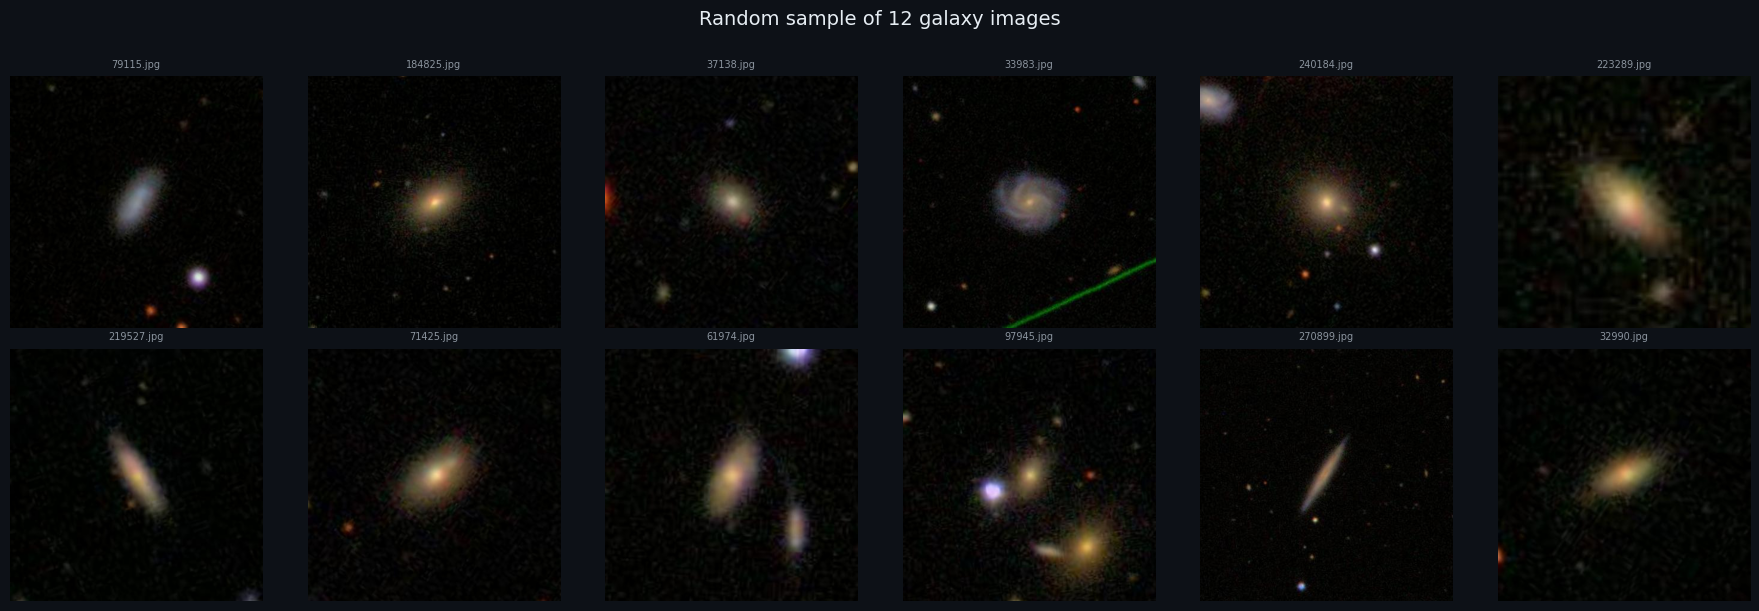

In [15]:
# Display a random sample of 12 galaxy images
sample_paths = np.random.choice(image_files, size=12, replace=False)

fig, axes = plt.subplots(2, 6, figsize=(18, 6), facecolor="#0d1117")
fig.suptitle("Random sample of 12 galaxy images", color="#e6edf3", fontsize=14, y=1.01)

for ax, img_path in zip(axes.flat, sample_paths):
    with Image.open(img_path) as img:
        ax.imshow(img)
    ax.set_title(img_path.name, color="#8b949e", fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.show()

---
## Sección 6 — Estructura del árbol de decisión GZ2

El árbol de decisión del Galaxy Zoo 2 tiene **11 preguntas** (tasks).  
Cada pregunta se aplica sólo a un subconjunto de galaxias según las respuestas anteriores.

```
T01: ¿Es suave o tiene características/disco?
 ├── smooth          ──► T06 (¿es rara?)
 │                       └── T07 (¿qué tan redonda?)    ──► ELLIPTICAL
 ├── features_or_disk ──► T02 (¿se ve de canto?)
 │    ├── edge-on YES ──► T09 (¿forma del bulbo?)       ──► EDGE-ON
 │    └── edge-on NO  ──► T03 (¿tiene barra?)
 │                        ├── bar      ──► T04 (¿espiral?)
 │                        │   └── spiral ──► T10/T11    ──► BARRED SPIRAL
 │                        └── no bar   ──► T04 (¿espiral?)
 │                            ├── spiral  ──► T10/T11   ──► SPIRAL
 │                            └── no spiral             ──► LENTICULAR (S0)
 └── star_or_artifact ──► DESCARTADA
```

La columna clave es siempre la **`_debiased`** (fracción corregida por sesgo de Hart et al.).

In [16]:
# Decision-tree mapping table
tree_map = [
    # task, answer, debiased_col, morphology_role
    ("T01", "smooth",             "t01_smooth_or_features_a01_smooth_debiased",                      "→ Elliptical candidate"),
    ("T01", "features_or_disk",   "t01_smooth_or_features_a02_features_or_disk_debiased",            "→ Disk galaxy (spiral/S0/edge-on)"),
    ("T01", "star_or_artifact",   "t01_smooth_or_features_a03_star_or_artifact_debiased",            "→ DISCARD"),
    ("T02", "edge-on YES",        "t02_edgeon_a04_yes_debiased",                                     "→ Edge-on galaxy"),
    ("T02", "edge-on NO",         "t02_edgeon_a05_no_debiased",                                      "→ Face-on disk"),
    ("T03", "bar",                "t03_bar_a06_bar_debiased",                                        "→ Barred spiral"),
    ("T03", "no_bar",             "t03_bar_a07_no_bar_debiased",                                     "→ Unbarred spiral or S0"),
    ("T04", "spiral",             "t04_spiral_a08_spiral_debiased",                                  "→ Spiral (barred or not)"),
    ("T04", "no_spiral",          "t04_spiral_a09_no_spiral_debiased",                               "→ Lenticular (S0)"),
    ("T06", "odd",                "t06_odd_a14_yes_debiased",                                        "→ Irregular / odd"),
    ("T07", "completely_round",   "t07_rounded_a16_completely_round_debiased",                       "→ Round elliptical"),
    ("T07", "in_between",         "t07_rounded_a17_in_between_debiased",                             "→ Intermediate elliptical"),
    ("T07", "cigar_shaped",       "t07_rounded_a18_cigar_shaped_debiased",                           "→ Cigar/elongated elliptical"),
    ("T08", "merger",             "t08_odd_feature_a38_merger_debiased",                             "→ Merger"),
    ("T08", "disturbed",          "t08_odd_feature_a24_disturbed_debiased",                          "→ Disturbed/Irregular"),
    ("T09", "no_bulge",           "t09_bulge_shape_a27_no_bulge_debiased",                           "→ Edge-on thin disk"),
]

tree_df = pd.DataFrame(tree_map, columns=["Task", "Answer", "Debiased_column", "Morphology_role"])
display(tree_df)

,Task,Answer,Debiased_column,Morphology_role
0,T01,smooth,t01_smooth_or_features_a01_smooth_debiased,→ Elliptical candidate
1,T01,features_or_disk,t01_smooth_or_features_a02_features_or_disk_de...,→ Disk galaxy (spiral/S0/edge-on)
2,T01,star_or_artifact,t01_smooth_or_features_a03_star_or_artifact_de...,→ DISCARD
3,T02,edge-on YES,t02_edgeon_a04_yes_debiased,→ Edge-on galaxy
4,T02,edge-on NO,t02_edgeon_a05_no_debiased,→ Face-on disk
5,T03,bar,t03_bar_a06_bar_debiased,→ Barred spiral
6,T03,no_bar,t03_bar_a07_no_bar_debiased,→ Unbarred spiral or S0
7,T04,spiral,t04_spiral_a08_spiral_debiased,→ Spiral (barred or not)
8,T04,no_spiral,t04_spiral_a09_no_spiral_debiased,→ Lenticular (S0)
9,T06,odd,t06_odd_a14_yes_debiased,→ Irregular / odd


In [17]:
# Verify that the referenced debiased columns exist in the dataset
missing_cols = [row["Debiased_column"] for _, row in tree_df.iterrows()
                if row["Debiased_column"] not in hart.columns]

if missing_cols:
    print("WARNING — the following columns were NOT found in hart16:")
    for c in missing_cols:
        print(f"  ✗ {c}")
else:
    print("All debiased columns verified in hart16 ✓")

WARNING — the following columns were NOT found in hart16:
  ✗ t08_odd_feature_a38_merger_debiased
  ✗ t08_odd_feature_a24_disturbed_debiased


---
## Sección 7 — Distribución de fracciones de votos

Analizamos los histogramas de las columnas `_debiased` más relevantes para determinar si son bimodales (buen umbral de corte) o planas (difíciles de clasificar).

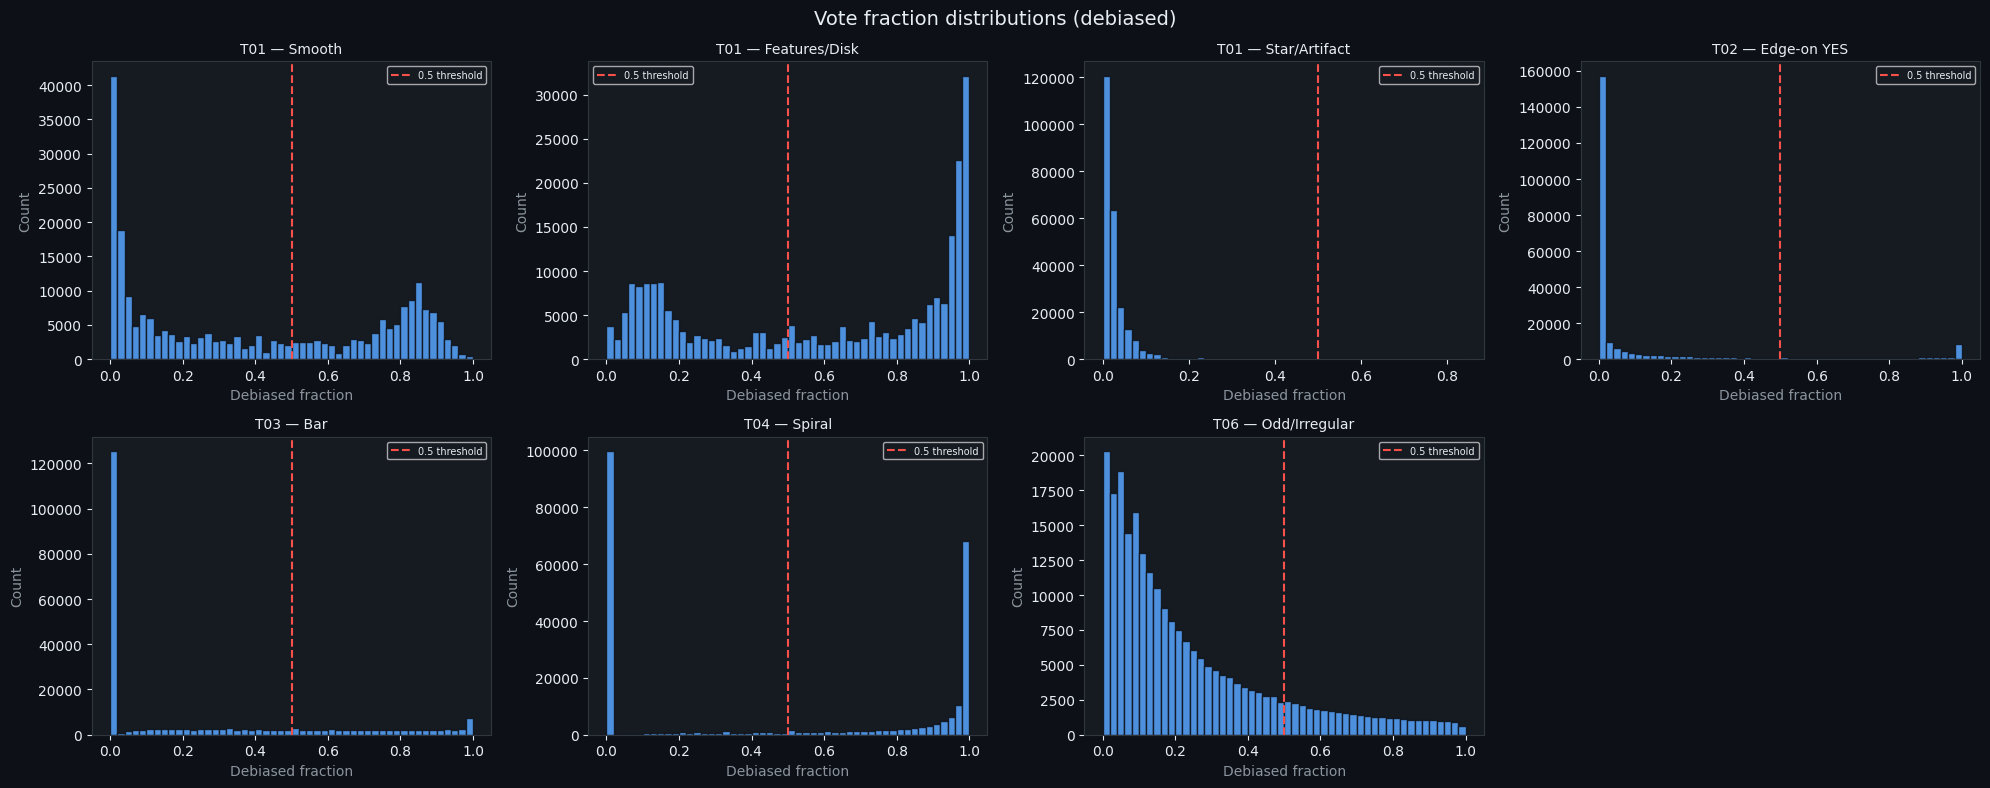

In [18]:
# Key debiased columns for morphology separation
key_cols = {
    "T01 — Smooth":           "t01_smooth_or_features_a01_smooth_debiased",
    "T01 — Features/Disk":    "t01_smooth_or_features_a02_features_or_disk_debiased",
    "T01 — Star/Artifact":    "t01_smooth_or_features_a03_star_or_artifact_debiased",
    "T02 — Edge-on YES":      "t02_edgeon_a04_yes_debiased",
    "T03 — Bar":              "t03_bar_a06_bar_debiased",
    "T04 — Spiral":           "t04_spiral_a08_spiral_debiased",
    "T06 — Odd/Irregular":    "t06_odd_a14_yes_debiased",
}

fig, axes = plt.subplots(2, 4, figsize=(20, 8), facecolor="#0d1117")
fig.suptitle("Vote fraction distributions (debiased)", color="#e6edf3", fontsize=14)

for ax, (label, col) in zip(axes.flat, key_cols.items()):
    data = hart[col].dropna()
    ax.hist(data, bins=50, color="#58a6ff", edgecolor="#0d1117", alpha=0.85)
    ax.axvline(0.5, color="#f85149", linewidth=1.5, linestyle="--", label="0.5 threshold")
    ax.set_title(label, color="#e6edf3", fontsize=10)
    ax.set_xlabel("Debiased fraction", color="#8b949e")
    ax.set_ylabel("Count", color="#8b949e")
    ax.legend(fontsize=7)

# Hide the spare subplot
axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

---
## Sección 8 — Definición de clases y exploración de umbrales

Evaluamos cómo cambia el tamaño de cada clase morfológica en función del umbral de confianza aplicado a las fracciones `_debiased`.

### Reglas de asignación (prioridad de arriba hacia abajo)

| Prioridad | Clase | Condición |
|-----------|-------|-----------|
| 1 | **Artifact** | `t01_star_debiased >= threshold` → DESCARTAR |
| 2 | **Edge-on** | `t01_features_debiased >= threshold` AND `t02_edgeon_yes_debiased >= threshold` |
| 3 | **Barred Spiral** | `t01_features_debiased >= threshold` AND `t02_edgeon_no_debiased >= threshold` AND `t03_bar_debiased >= threshold` AND `t04_spiral_debiased >= threshold` |
| 4 | **Spiral** | `t01_features_debiased >= threshold` AND `t02_edgeon_no_debiased >= threshold` AND `t03_no_bar_debiased >= threshold` AND `t04_spiral_debiased >= threshold` |
| 5 | **Lenticular** | `t01_features_debiased >= threshold` AND `t04_no_spiral_debiased >= threshold` AND `t02_edgeon_no_debiased >= threshold` |
| 6 | **Elliptical** | `t01_smooth_debiased >= threshold` |
| 7 | **Irregular** | `t06_odd_debiased >= threshold` |

In [19]:
def assign_class(df: pd.DataFrame, threshold: float) -> pd.Series:
    """
    Assign a morphological label to each galaxy using sequential priority rules.
    Galaxies that do not meet any threshold are labelled 'Uncertain'.
    """
    # Shorthand aliases
    smooth       = df["t01_smooth_or_features_a01_smooth_debiased"]
    features     = df["t01_smooth_or_features_a02_features_or_disk_debiased"]
    artifact     = df["t01_smooth_or_features_a03_star_or_artifact_debiased"]
    edgeon_yes   = df["t02_edgeon_a04_yes_debiased"]
    edgeon_no    = df["t02_edgeon_a05_no_debiased"]
    bar          = df["t03_bar_a06_bar_debiased"]
    no_bar       = df["t03_bar_a07_no_bar_debiased"]
    spiral       = df["t04_spiral_a08_spiral_debiased"]
    no_spiral    = df["t04_spiral_a09_no_spiral_debiased"]
    odd          = df["t06_odd_a14_yes_debiased"]

    labels = pd.Series("Uncertain", index=df.index)

    # Priority 7 — Irregular (lowest, overridden by more specific rules)
    labels[odd >= threshold] = "Irregular"

    # Priority 6 — Elliptical
    labels[smooth >= threshold] = "Elliptical"

    # Priority 5 — Lenticular (S0): disk but no spiral, seen face-on
    lenticular_mask = (features >= threshold) & (edgeon_no >= threshold) & (no_spiral >= threshold)
    labels[lenticular_mask] = "Lenticular"

    # Priority 4 — Spiral (unbarred)
    spiral_mask = (features >= threshold) & (edgeon_no >= threshold) & (no_bar >= threshold) & (spiral >= threshold)
    labels[spiral_mask] = "Spiral"

    # Priority 3 — Barred Spiral
    barred_mask = (features >= threshold) & (edgeon_no >= threshold) & (bar >= threshold) & (spiral >= threshold)
    labels[barred_mask] = "Barred_Spiral"

    # Priority 2 — Edge-on
    edgeon_mask = (features >= threshold) & (edgeon_yes >= threshold)
    labels[edgeon_mask] = "Edge_on"

    # Priority 1 — Artifact (always discard)
    labels[artifact >= threshold] = "Artifact"

    return labels

print("assign_class() defined ✓")

assign_class() defined ✓


In [20]:
# Test multiple thresholds and compute class sizes
THRESHOLDS = [0.5, 0.6, 0.7, 0.8]
CLASS_ORDER = ["Elliptical", "Lenticular", "Spiral", "Barred_Spiral", "Edge_on", "Irregular", "Artifact", "Uncertain"]

rows = []
for thr in THRESHOLDS:
    labels = assign_class(hart, thr)
    counts = labels.value_counts()
    row = {"threshold": thr}
    for cls in CLASS_ORDER:
        row[cls] = int(counts.get(cls, 0))
    row["Total_labeled"] = int((labels != "Uncertain").sum())
    row["Coverage_%"] = round((labels != "Uncertain").mean() * 100, 1)
    rows.append(row)

threshold_df = pd.DataFrame(rows).set_index("threshold")
display(threshold_df)

,Elliptical,Lenticular,Spiral,Barred_Spiral,Edge_on,Irregular,Artifact,Uncertain,Total_labeled,Coverage_%
threshold,,,,,,,,,,
0.5000,84874,25009,54037,37723,20581,3478,12,13981,225714,94.2000
0.6000,79198,18853,41928,29131,16538,7157,8,46882,192813,80.4000
0.7000,71689,13491,30066,21482,12933,7805,6,82223,157472,65.7000
0.8000,52455,9089,18570,14761,9364,6529,3,128924,110771,46.2000


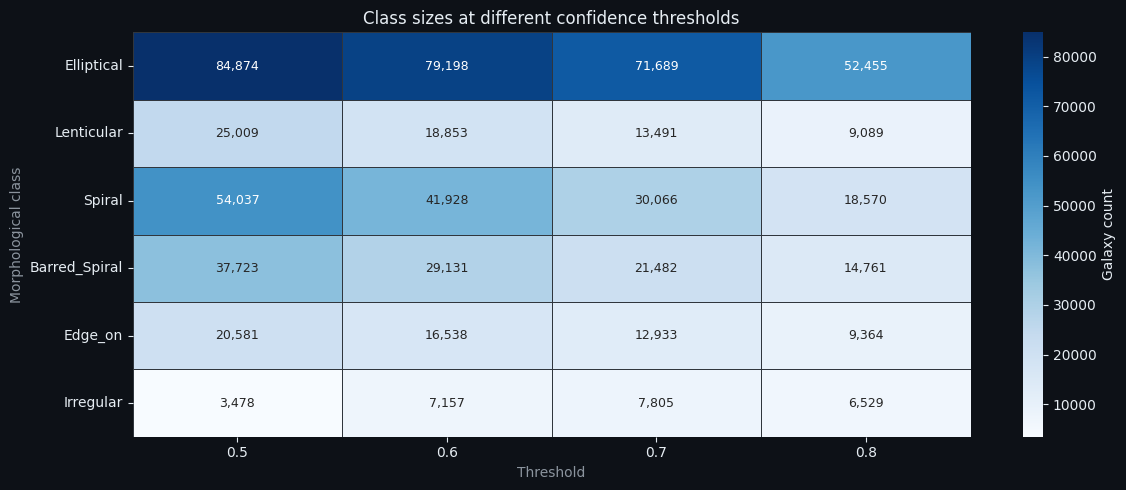

In [21]:
# Heatmap of class counts per threshold
plot_cols = [c for c in CLASS_ORDER if c not in ("Artifact", "Uncertain")]
data_plot = threshold_df[plot_cols].T

fig, ax = plt.subplots(figsize=(12, 5), facecolor="#0d1117")
sns.heatmap(
    data_plot,
    annot=True, fmt=",", cmap="Blues",
    linewidths=0.5, linecolor="#30363d",
    ax=ax, cbar_kws={"label": "Galaxy count"},
    annot_kws={"size": 9},
)
ax.set_title("Class sizes at different confidence thresholds", color="#e6edf3")
ax.set_xlabel("Threshold", color="#8b949e")
ax.set_ylabel("Morphological class", color="#8b949e")
ax.tick_params(colors="#e6edf3")
plt.tight_layout()
plt.show()

---
## Sección 9 — Visualización del desbalance de clases

Usamos el umbral **0.6** como candidato principal (buen equilibrio entre cobertura y confianza).  
Visualizamos el desbalance resultante y calculamos los ratios de desbalance.

In [22]:
CANDIDATE_THRESHOLD = 0.6

labels_candidate = assign_class(hart, CANDIDATE_THRESHOLD)

# Exclude Artifact and Uncertain from the final count
valid_labels = labels_candidate[~labels_candidate.isin(["Artifact", "Uncertain"])]
class_counts = valid_labels.value_counts().reindex(
    [c for c in CLASS_ORDER if c not in ("Artifact", "Uncertain")]
).dropna().astype(int)

print(f"Threshold      : {CANDIDATE_THRESHOLD}")
print(f"Total labeled  : {len(valid_labels):,}")
print(f"Artifact/Uncert excluded: {(labels_candidate.isin(['Artifact','Uncertain'])).sum():,}")
print()
print(class_counts.rename("count").to_string())

majority = class_counts.max()
print(f"\nImbalance ratio (majority / minority): {majority / class_counts.min():.1f}x")

Threshold      : 0.6
Total labeled  : 192,805
Artifact/Uncert excluded: 46,890

Elliptical       79198
Lenticular       18853
Spiral           41928
Barred_Spiral    29131
Edge_on          16538
Irregular         7157

Imbalance ratio (majority / minority): 11.1x


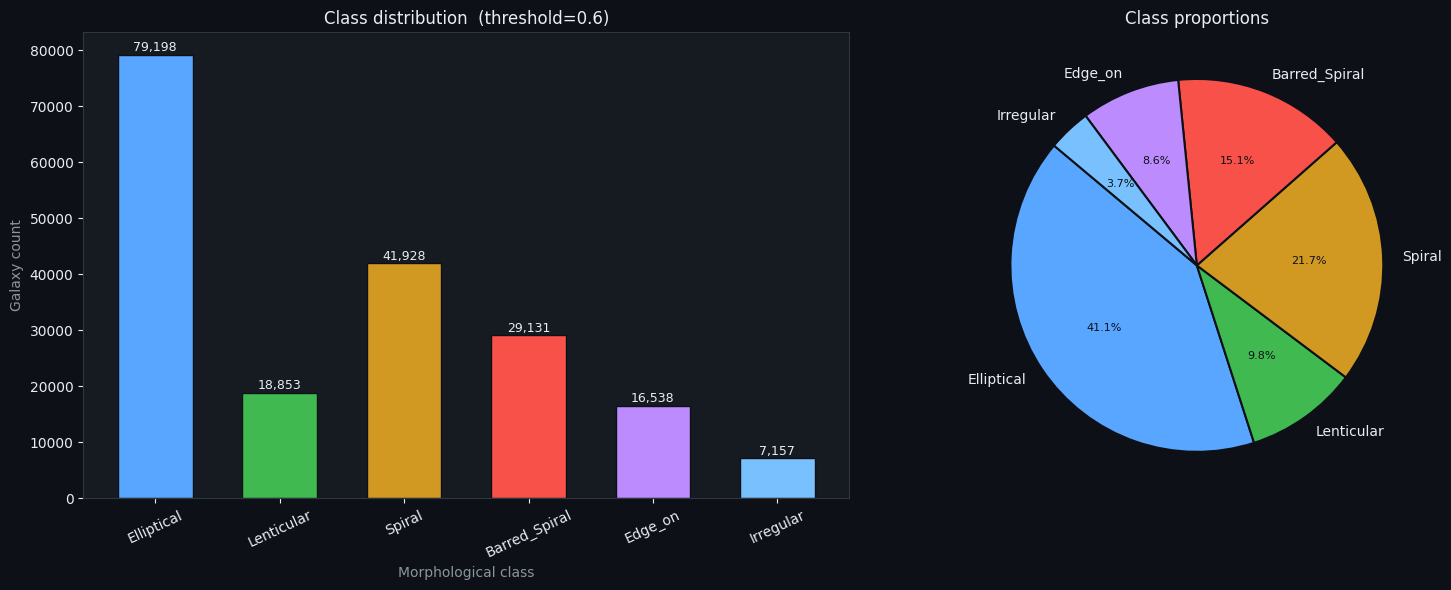

In [23]:
# Bar chart + pie chart side-by-side
PALETTE = ["#58a6ff", "#3fb950", "#d29922", "#f85149", "#bc8cff", "#79c0ff"]

fig, (ax_bar, ax_pie) = plt.subplots(1, 2, figsize=(16, 6), facecolor="#0d1117")

# Bar chart
bars = ax_bar.bar(class_counts.index, class_counts.values,
                  color=PALETTE[:len(class_counts)], edgecolor="#0d1117", width=0.6)
ax_bar.set_title(f"Class distribution  (threshold={CANDIDATE_THRESHOLD})", color="#e6edf3")
ax_bar.set_ylabel("Galaxy count", color="#8b949e")
ax_bar.set_xlabel("Morphological class", color="#8b949e")
for bar, val in zip(bars, class_counts.values):
    ax_bar.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                f"{val:,}", ha="center", va="bottom", color="#e6edf3", fontsize=9)
ax_bar.tick_params(axis="x", rotation=25)

# Pie chart
wedges, texts, autotexts = ax_pie.pie(
    class_counts.values,
    labels=class_counts.index,
    autopct="%1.1f%%",
    colors=PALETTE[:len(class_counts)],
    startangle=140,
    wedgeprops={"edgecolor": "#0d1117", "linewidth": 1.5},
    textprops={"color": "#e6edf3"},
)
for autotext in autotexts:
    autotext.set_color("#0d1117")
    autotext.set_fontsize(8)
ax_pie.set_title("Class proportions", color="#e6edf3")

plt.tight_layout()
plt.show()

In [24]:
# Imbalance ratio table per class vs majority
imbalance_df = pd.DataFrame({
    "count": class_counts,
    "% of total": (class_counts / class_counts.sum() * 100).round(2),
    "ratio_to_majority": (majority / class_counts).round(1),
})
imbalance_df = imbalance_df.sort_values("count", ascending=False)
print("=== Imbalance analysis ===")
display(imbalance_df)

=== Imbalance analysis ===


,count,% of total,ratio_to_majority
Elliptical,79198,41.0800,1.0000
Spiral,41928,21.7500,1.9000
Barred_Spiral,29131,15.1100,2.7000
Lenticular,18853,9.7800,4.2000
Edge_on,16538,8.5800,4.8000
Irregular,7157,3.7100,11.1000


---
## Sección 10 — Muestra de imágenes por clase morfológica

Verificación visual: ¿corresponden las etiquetas asignadas con el aspecto visual esperado de cada tipo de galaxia?

In [25]:
# Build a working dataframe: hart + asset_id + candidate label
hart["morph_label"] = labels_candidate
hart["asset_id"] = merged["asset_id"]

# Restrict to galaxies that have an image on disk
hart["img_path"] = hart["asset_id"].apply(
    lambda aid: IMAGES_DIR / f"{int(aid)}.jpg" if pd.notna(aid) else None
)
hart_with_img = hart[
    hart["img_path"].apply(lambda p: p is not None and p.exists())
].copy()

print(f"Galaxies with label + image on disk : {len(hart_with_img):,}")

Galaxies with label + image on disk : 209,240


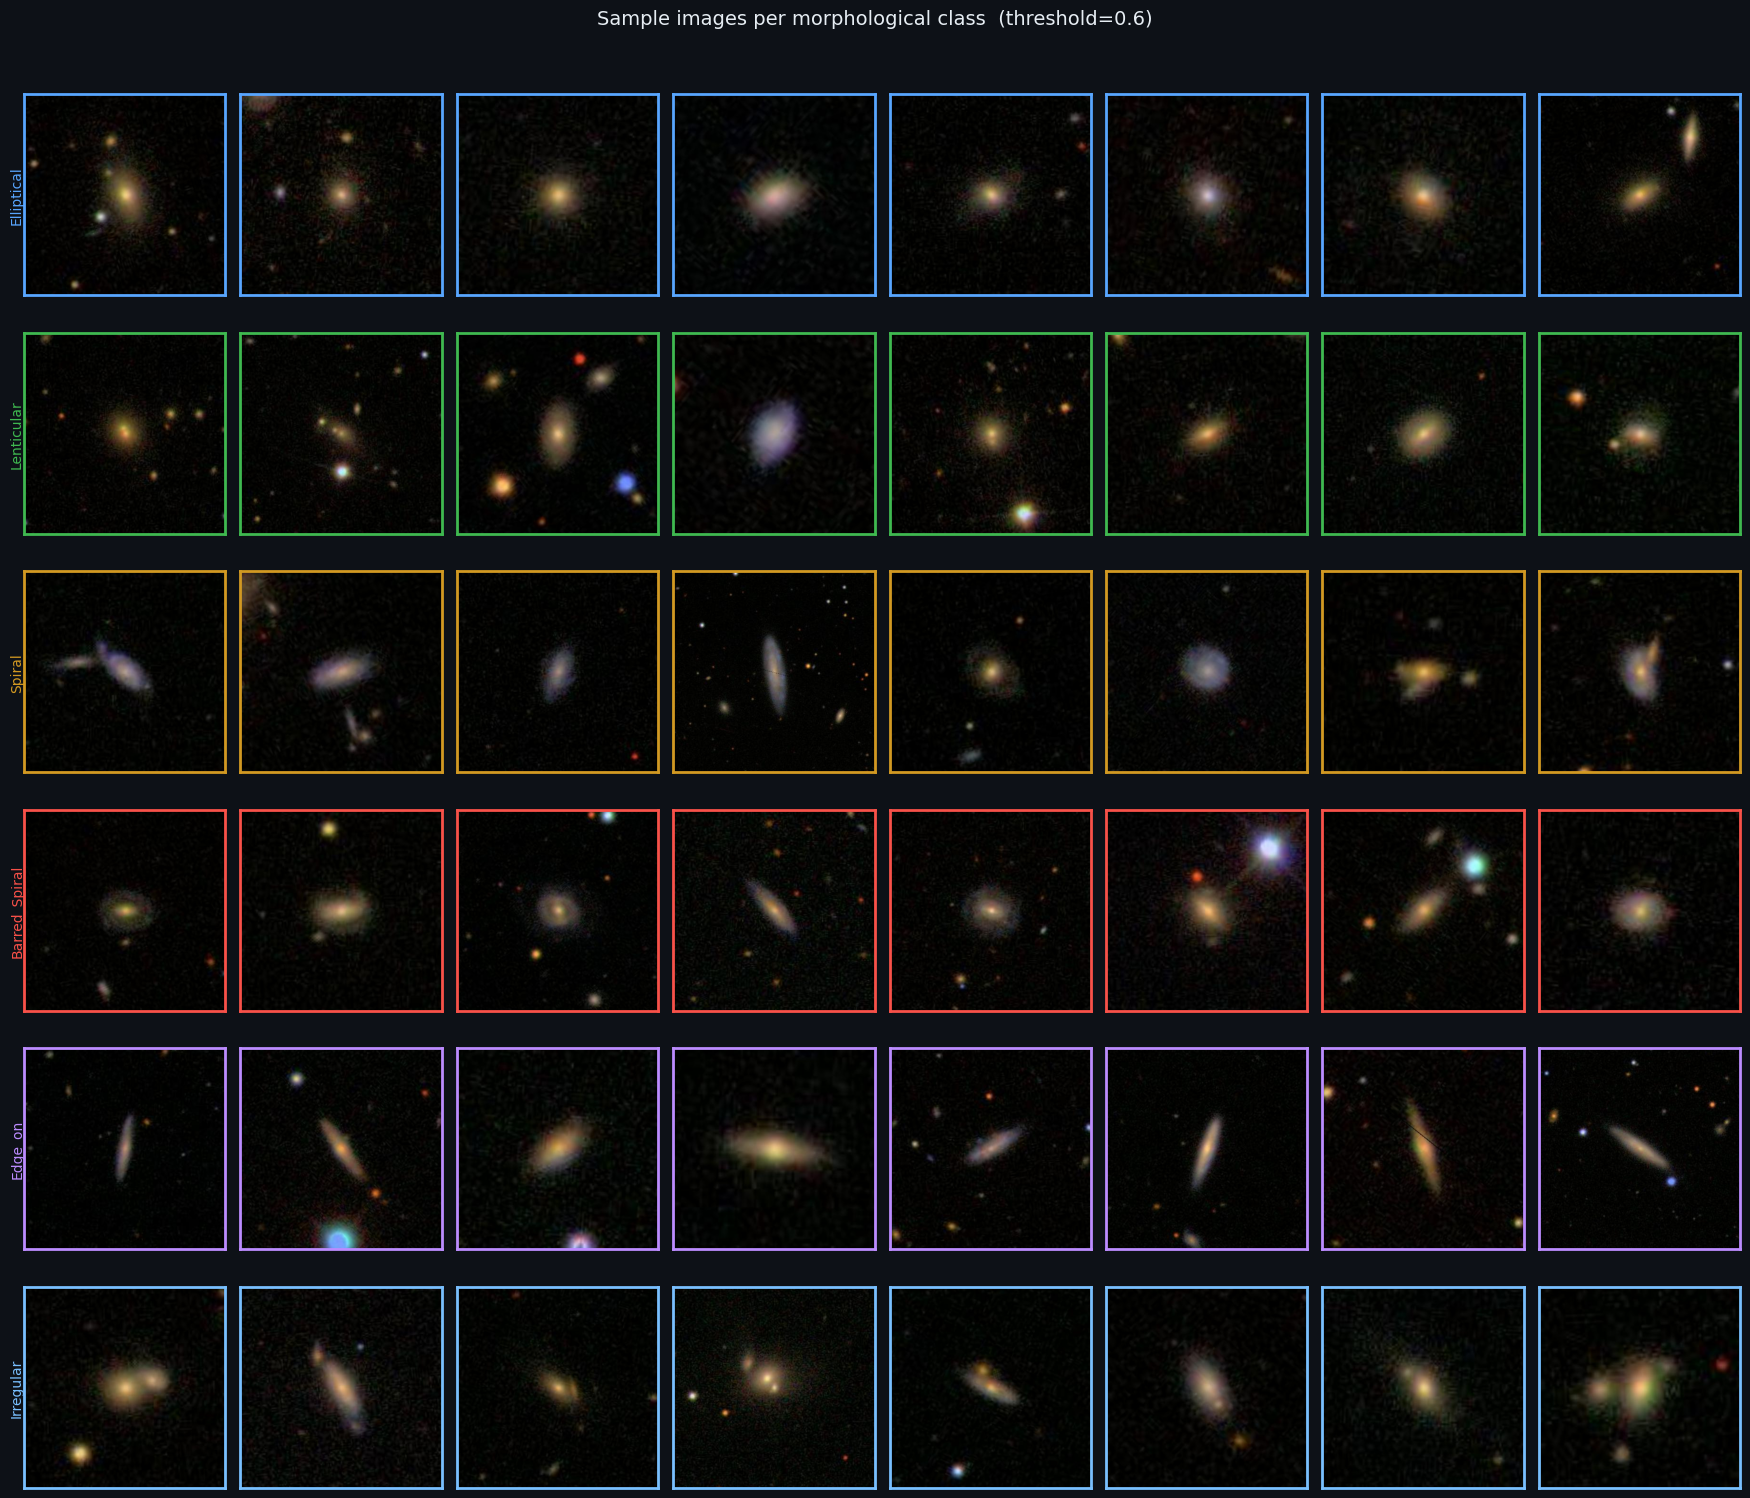

In [26]:
DISPLAY_CLASSES = [c for c in CLASS_ORDER if c not in ("Artifact", "Uncertain")]
N_SAMPLES = 8

fig, axes = plt.subplots(
    len(DISPLAY_CLASSES), N_SAMPLES,
    figsize=(N_SAMPLES * 2.2, len(DISPLAY_CLASSES) * 2.5),
    facecolor="#0d1117"
)
fig.suptitle(
    f"Sample images per morphological class  (threshold={CANDIDATE_THRESHOLD})",
    color="#e6edf3", fontsize=14, y=1.01
)

CLASS_COLORS = {
    "Elliptical":    "#58a6ff",
    "Lenticular":    "#3fb950",
    "Spiral":        "#d29922",
    "Barred_Spiral": "#f85149",
    "Edge_on":       "#bc8cff",
    "Irregular":     "#79c0ff",
}

for row_idx, cls in enumerate(DISPLAY_CLASSES):
    subset = hart_with_img[hart_with_img["morph_label"] == cls]
    sample_rows = subset.sample(n=min(N_SAMPLES, len(subset)), random_state=SEED)

    for col_idx in range(N_SAMPLES):
        ax = axes[row_idx, col_idx]
        if col_idx < len(sample_rows):
            img_path = sample_rows.iloc[col_idx]["img_path"]
            with Image.open(img_path) as img:
                ax.imshow(img)
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_edgecolor(CLASS_COLORS.get(cls, "#ffffff"))
                spine.set_linewidth(2)
        else:
            ax.set_visible(False)

        if col_idx == 0:
            ax.set_ylabel(cls, color=CLASS_COLORS.get(cls, "#ffffff"),
                          fontsize=10, rotation=90, labelpad=5, va="center")

plt.tight_layout()
plt.show()

---
## Sección 11 — Conclusiones y próximos pasos

### Hallazgos de la EDA

| Aspecto | Observación |
|---------|-------------|
| **Galaxias en hart16** | 239,695 con fracciones de votos debiased |
| **Imágenes en disco** | ~243,434 archivos `.jpg` |
| **Overlap útil** | ~239,xxx galaxias con label + imagen (confirmar en celda anterior) |
| **Distribuciones** | T01 (smooth/features) y T04 (spiral) son claramente bimodales → buenos umbrales |
| **Desbalance** | Elípticas >> Espirales >> Edge-on >> Barradas >> Lenticulares > Irregulares |
| **Umbral candidato** | **0.6** equilibra cobertura y certeza |

### Estrategia para el desbalance de clases

Los notebooks siguientes aplicarán:
1. **Oversampling** de clases minoritarias con augmentación (flip, rotación, brillo)
2. **Undersampling** controlado de la clase mayoritaria (Elliptical)
3. **Class weights** en la función de pérdida de la CNN

### Plan de notebooks

| Notebook | Contenido |
|----------|-----------|
| `01_eda.ipynb` ← *este* | Exploración de datos y definición de clases |
| `02_dataset_preparation.ipynb` | Filtrado, merge final, hard-labels, export a CSV |
| `03_image_preprocessing.ipynb` | Normalización, resize, augmentación, QC de imágenes |
| `04_model_training.ipynb` | Arquitectura CNN, entrenamiento, callbacks |
| `05_evaluation.ipynb` | Métricas, matriz de confusión, análisis de errores |